# 주 패스트볼 K-Means 클러스터링 — 전체 파이프라인 (step1 ~ step6 통합)

**분석 단위**: 투수-시즌별 주 패스트볼 프로필 (2021–2025 MLB 정규시즌, Statcast)

| 절 | 내용 | 원래 파일 |
|---|---|---|
| 1 | raw CSV 로드 → 전처리 → 결측치 점검 | `step1_load_and_clean.py` |
| 2 | 체공시간 보정 무브먼트(`ivb_ft`, `hb_ft`) 계산 | `step2_flight_time_adjust.py` |
| 3 | 투수-시즌별 주 패스트볼 식별 → 피처 테이블 | `step3_build_profile_table.py` |
| 4 | 표준화 → k 탐색 (elbow / silhouette / PCA 비교) | `step4_kmeans_clustering.py`, `step5` |
| 5 | 최종 k 확정 → 클러스터 프로파일링 | `step5_kmeans_finalize.ipynb` |
| 6 | 실제 구종(FF/SI/FC) 교차표 검증 → 팀 비교 지표 → 저장 | `step6_kmeans_conclusion.ipynb` |

**실행 방법**: 레포 안(`data/` 폴더가 있는 레포 루트 또는 그 하위 폴더, 예: `notebooks/`)에 이 파일을 두고 위에서부터 **Run All**.

- 1~3절 산출물(`data/processed/interim/*.pkl`)이 이미 있으면 다시 계산하지 않고 불러온다 (raw CSV 로드가 오래 걸리기 때문).
- 전처리 설정을 바꿨다면 아래 설정 셀의 `FORCE_RERUN = True`로 바꿔서 처음부터 다시 계산한다.

## 0. 환경 설정

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:          # 노트북 밖(순수 파이썬)에서 실행할 때 대비
    display = print

# 한글 폰트 설정 (제목/라벨 깨짐 방지)
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _font_name in ("AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font_name in _available_fonts:
        plt.rcParams["font.family"] = _font_name
        break
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.precision", 2)
pd.set_option("display.max_columns", 50)

In [2]:
# ============================================================
# 경로 / 전체 설정 (모든 단계 공통 — 바꿀 값은 여기서만)
# ============================================================
def _find_repo_root() -> Path:
    """노트북 위치(레포 루트 또는 notebooks/ 등 하위 폴더)에서 위로 올라가며
    ".git" 폴더나 "data" 폴더가 있는 위치를 레포 루트로 판단한다."""
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() or (candidate / "data").is_dir():
            return candidate
    return start


ROOT = _find_repo_root()


def rel(p: Path) -> str:
    """출력용: 레포 루트 기준 상대경로 (공개 레포라 절대경로/사용자명이 노출되지 않게)."""
    try:
        return Path(p).resolve().relative_to(ROOT).as_posix()
    except ValueError:
        return Path(p).name


RAW_DIR = ROOT / "data" / "raw"
INTERIM_DIR = ROOT / "data" / "processed" / "interim"
OUTPUT_DIR = ROOT / "data" / "processed" / "output"
INTERIM_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# 캐시: False면 interim pkl이 있을 때 재사용, True면 raw CSV부터 전부 다시 계산
FORCE_RERUN = False

# --- 1단계 ---
PITCH_TYPES = ["FF", "SI", "FC"]            # 주 패스트볼 후보 계열
TARGET_YEARS = [2021, 2022, 2023, 2024, 2025]
REQUIRED_COLUMNS = {
    "pitcher", "player_name", "game_year", "game_type",
    "pitch_type", "description",
    "release_speed", "release_pos_x", "release_pos_y", "release_pos_z",
    "release_extension", "release_spin_rate", "spin_axis", "arm_angle",
    "pfx_x", "pfx_z", "p_throws", "stand",
    "vx0", "vy0", "vz0", "ax", "ay", "az",
    "plate_x", "plate_z",
}

# --- 2단계 ---
TRAIN_YEARS = [2021, 2022, 2023]            # 기준 체공시간 학습 연도 (고정)
PLATE_Y_FT = 17.0 / 12.0
REFERENCE_Y_FT = 50.0
MIN_FLIGHT_TIME_S = 0.25
MAX_FLIGHT_TIME_S = 0.60

# --- 3단계 ---
MIN_PITCHES_PER_PITCHER_SEASON = 300

# --- 4~6단계 ---
FEATURE_COLS = [
    "release_speed",
    "ivb_ft",
    "hb_ft",
    "arm_angle",
    "release_pos_x",
    "release_pos_z",
    "release_extension",
]
K_CANDIDATES = range(2, 11)                 # k=2 ~ 10 탐색
COMPARE_KS = [2, 3, 4]                      # PCA로 나란히 비교할 후보
FINAL_K = 3                                 # 4절 결과를 보고 확정 (바꾸면 5절부터 다시 실행)
RANDOM_STATE = 42

CLEAN_PKL = INTERIM_DIR / "pitches_clean.pkl"
MOVEMENT_PKL = INTERIM_DIR / "pitches_with_movement.pkl"
PROFILE_PKL = INTERIM_DIR / "fastball_profile_table.pkl"

print(f"레포 루트 폴더명: {ROOT.name}")
print(f"raw 데이터: {rel(RAW_DIR)}/  (존재: {RAW_DIR.is_dir()})")

레포 루트 폴더명: 9th-first-project-baseball-1
raw 데이터: data/raw/  (존재: True)


## 1. raw Statcast CSV 로드 → 전처리 → 결측치 점검

- `data/raw/` 아래 CSV를 하위 폴더까지 전부 찾아서 읽는다 (Excel/Numbers 임시 잠금 파일 `~$...` 제외).
- 메모리 절약을 위해 **필요한 칼럼만** 읽는다 (Statcast 원본은 칼럼이 100개가 넘음).
- 정규시즌(`game_type == "R"`), 대상 연도, pitchout 제외, 좌/우 표기 정상값만 남긴다.

In [3]:
def load_raw(raw_dir: Path) -> pd.DataFrame:
    all_files = sorted(raw_dir.rglob("*.csv"))
    files = [f for f in all_files
             if not f.name.startswith(("~$", ".")) and "~$" not in f.name]
    skipped = sorted(set(all_files) - set(files))

    if not files:
        raise FileNotFoundError(
            f"{rel(raw_dir)} 안에 csv가 없습니다. Baseball Savant에서 내려받은 "
            "pitch-level CSV를 이 폴더(하위 폴더 포함)에 넣어주세요."
        )
    if skipped:
        print(f"[load_raw] 임시/잠금 파일로 판단되어 건너뜀: {[f.name for f in skipped]}")

    frames = []
    for f in files:
        try:
            frames.append(pd.read_csv(
                f, low_memory=False,
                usecols=lambda c: c in REQUIRED_COLUMNS,   # 필요한 칼럼만
            ))
        except Exception as e:
            print(f"[load_raw] 읽기 실패, 건너뜀: {rel(f)} ({e})")
    if not frames:
        raise RuntimeError("읽을 수 있는 CSV가 하나도 없습니다. 위 '읽기 실패' 메시지를 확인하세요.")

    data = pd.concat(frames, ignore_index=True)
    print(f"[load_raw] 파일 {len(frames)}개, 총 {len(data):,}행 로드")
    return data


def basic_preprocess(data: pd.DataFrame) -> pd.DataFrame:
    missing = REQUIRED_COLUMNS.difference(data.columns)
    if missing:
        raise KeyError(f"필수 칼럼이 없습니다: {sorted(missing)}")

    data = data.copy()
    numeric_cols = [
        "game_year", "release_speed", "release_pos_x", "release_pos_y",
        "release_pos_z", "release_extension", "release_spin_rate",
        "spin_axis", "arm_angle", "pfx_x", "pfx_z",
        "vx0", "vy0", "vz0", "ax", "ay", "az", "plate_x", "plate_z",
    ]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    before = len(data)
    mask = (
        (data["game_type"] == "R")
        & data["game_year"].isin(TARGET_YEARS)
        & (data["description"] != "pitchout")
        & data["p_throws"].isin(["R", "L"])
    )
    data = data.loc[mask].copy()
    data["game_year"] = data["game_year"].astype(int)

    # 전체 구종 유지, FF/SI/FC 여부만 표시 (실제 필터링은 3절에서)
    data["is_fastball_candidate"] = data["pitch_type"].isin(PITCH_TYPES)

    print(f"[basic_preprocess] {before:,} -> {len(data):,}행 (정규시즌/연도/pitchout/좌우표기 필터 후)")
    return data.reset_index(drop=True)


def missing_value_report(data: pd.DataFrame, columns: list) -> pd.DataFrame:
    report = (
        data[columns].isna().mean()
        .sort_values(ascending=False)
        .to_frame("missing_rate")
    )
    report["missing_rate_pct"] = (report["missing_rate"] * 100).round(2)
    return report

In [4]:
CHECK_COLS = [
    "release_speed", "pfx_x", "pfx_z", "arm_angle",
    "release_pos_x", "release_pos_y", "release_pos_z",
    "release_extension", "vy0", "ay",
]

if CLEAN_PKL.exists() and not FORCE_RERUN:
    df_clean = pd.read_pickle(CLEAN_PKL)
    print(f"[캐시] {CLEAN_PKL.name} 불러옴 ({len(df_clean):,}행)")
else:
    df_clean = load_raw(RAW_DIR)
    df_clean = basic_preprocess(df_clean)
    df_clean.to_pickle(CLEAN_PKL)
    print(f"저장 완료: {rel(CLEAN_PKL)} ({len(df_clean):,}행)")

print("\n[결측률 점검]")
display(missing_value_report(df_clean, CHECK_COLS))

[캐시] pitches_clean.pkl 불러옴 (3,452,659행)

[결측률 점검]


,missing_rate,missing_rate_pct
arm_angle,1.44e-02,1.44
release_extension,4.81e-03,0.48
release_pos_x,3.70e-03,0.37
release_pos_y,3.70e-03,0.37
release_pos_z,3.70e-03,0.37
pfx_x,3.64e-03,0.36
pfx_z,3.64e-03,0.36
vy0,3.64e-03,0.36
ay,3.64e-03,0.36
release_speed,3.64e-03,0.36


## 2. 체공시간 보정 무브먼트(`ivb_ft`, `hb_ft`) 계산

- `pfx_x`, `pfx_z`(ft) → 인치 변환, 수평 무브먼트는 **암사이드 양수**로 통일 (우투 ×(-12), 좌투 ×(+12)).
- Statcast 궤적(y=50ft 기준)에서 릴리스 → 홈플레이트 앞면까지 **체공시간**을 계산한다.
- 2021–2023 데이터로 구종별 **기준 체공시간(중앙값)**을 고정 학습하고,
  `(기준 체공시간 / 실제 체공시간)²`을 곱해 구속 차이로 생기는 무브먼트 차이를 보정한다.

In [5]:
def time_at_y(vy0, ay, target_y, reference_y=50.0):
    """Statcast y=50ft 기준 궤적에서 target_y 도달 시각 계산 (벡터화)."""
    vy = np.asarray(vy0, dtype=float)
    accel = np.asarray(ay, dtype=float)
    target = np.asarray(target_y, dtype=float)
    vy, accel, target = np.broadcast_arrays(vy, accel, target)

    c = reference_y - target
    with np.errstate(invalid="ignore", divide="ignore"):
        discriminant = vy**2 - 2.0 * accel * c
        result = np.full(vy.shape, np.nan, dtype=float)

        finite = (np.isfinite(vy) & np.isfinite(accel) & np.isfinite(target)
                  & (discriminant >= 0))

        linear = finite & np.isclose(accel, 0.0)
        if linear.any():
            result[linear] = np.divide(
                -c[linear], vy[linear],
                out=np.full(linear.sum(), np.nan),
                where=vy[linear] != 0,
            )

        quadratic = finite & ~linear
        sqrt_disc = np.sqrt(np.where(quadratic, discriminant, np.nan))
        root_1 = (-vy - sqrt_disc) / accel
        root_2 = (-vy + sqrt_disc) / accel
        nearest = np.where(np.abs(root_1) <= np.abs(root_2), root_1, root_2)
        result[quadratic] = nearest[quadratic]
    return result


def add_flight_time_adjusted_movement(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # raw -> inch
    data["ivb_raw_inches"] = data["pfx_z"] * 12.0
    data["hb_raw_inches"] = data["pfx_x"] * 12.0

    # 암사이드 양수로 통일 (우투 -12, 좌투 +12)
    hand_factor = data["p_throws"].map({"R": -12.0, "L": 12.0})
    data["hb_arm_side_inches"] = data["pfx_x"] * hand_factor

    # 체공시간
    release_time = time_at_y(data["vy0"], data["ay"], data["release_pos_y"],
                             reference_y=REFERENCE_Y_FT)
    plate_time = time_at_y(data["vy0"], data["ay"], PLATE_Y_FT,
                           reference_y=REFERENCE_Y_FT)
    data["flight_time_s"] = plate_time - release_time
    invalid = ~np.isfinite(data["flight_time_s"]) | (data["flight_time_s"] <= 0)
    data.loc[invalid, "flight_time_s"] = np.nan

    # 구종별 기준 체공시간 (2021-2023 고정 학습)
    valid_ref = (
        data["game_year"].isin(TRAIN_YEARS)
        & data["p_throws"].isin(["R", "L"])
        & data["flight_time_s"].between(MIN_FLIGHT_TIME_S, MAX_FLIGHT_TIME_S)
        & data[["ivb_raw_inches", "hb_arm_side_inches", "flight_time_s"]].notna().all(axis=1)
        & data["pitch_type"].isin(PITCH_TYPES)
    )
    reference_times = (
        data.loc[valid_ref]
        .groupby("pitch_type", observed=True)["flight_time_s"]
        .median()
    )
    missing_ref = set(PITCH_TYPES).difference(reference_times.index)
    if missing_ref:
        raise ValueError(f"기준 체공시간을 계산할 수 없는 구종: {sorted(missing_ref)}")

    data["reference_flight_time_s"] = data["pitch_type"].map(reference_times)

    valid_adj = data["flight_time_s"].gt(0) & data["reference_flight_time_s"].gt(0)
    data["flight_time_scale"] = np.where(
        valid_adj,
        (data["reference_flight_time_s"] / data["flight_time_s"]) ** 2,
        np.nan,
    )
    data["ivb_ft"] = data["ivb_raw_inches"] * data["flight_time_scale"]
    data["hb_ft"] = data["hb_arm_side_inches"] * data["flight_time_scale"]

    print("[flight_time_adjust] 구종별 기준 체공시간(초):")
    print(reference_times.round(4).to_string())
    return data

In [6]:
if MOVEMENT_PKL.exists() and not FORCE_RERUN:
    df_mv = pd.read_pickle(MOVEMENT_PKL)
    print(f"[캐시] {MOVEMENT_PKL.name} 불러옴 ({len(df_mv):,}행)")
else:
    df_mv = add_flight_time_adjusted_movement(df_clean)
    df_mv.to_pickle(MOVEMENT_PKL)
    print(f"저장 완료: {rel(MOVEMENT_PKL)} ({len(df_mv):,}행)")

# 1절 데이터는 더 이상 필요 없으므로 메모리 해제
del df_clean

display(
    df_mv.loc[df_mv["pitch_type"].isin(PITCH_TYPES)]
    .groupby("pitch_type")[["flight_time_s", "ivb_raw_inches", "ivb_ft", "hb_arm_side_inches", "hb_ft"]]
    .median()
)

[캐시] pitches_with_movement.pkl 불러옴 (3,452,659행)


,flight_time_s,ivb_raw_inches,ivb_ft,hb_arm_side_inches,hb_ft
pitch_type,,,,,
FC,0.42,7.80,7.92,-2.52,-2.60
FF,0.40,16.20,16.29,7.68,7.67
SI,0.40,8.52,8.50,15.36,15.34


## 3. 투수-시즌별 주 패스트볼 식별 → 클러스터링용 피처 테이블

- **주 패스트볼**: 투수-시즌별 FF/SI/FC 중 가장 많이 던진 계열 하나
- **최소 표본**: 주 패스트볼 투수-시즌당 300구 이상
- 피처 결측 투구는 0으로 채우지 않고 집계에서 제외한 뒤 투수-시즌 평균을 낸다.

In [7]:
def identify_primary_fastball(data: pd.DataFrame) -> pd.DataFrame:
    fb = data[data["pitch_type"].isin(PITCH_TYPES)]
    counts = (
        fb.groupby(["pitcher", "game_year", "pitch_type"], observed=True)
        .size()
        .rename("n_pitches")
        .reset_index()
    )
    idx = counts.groupby(["pitcher", "game_year"], observed=True)["n_pitches"].idxmax()
    primary = counts.loc[idx].rename(columns={"pitch_type": "primary_fastball_type"})
    print(f"[identify_primary_fastball] 투수-시즌 {len(primary):,}개 중 주 패스트볼 식별")
    return primary.reset_index(drop=True)


def build_profile_table(data: pd.DataFrame, primary: pd.DataFrame) -> pd.DataFrame:
    fb = data[data["pitch_type"].isin(PITCH_TYPES)]

    merged = fb.merge(
        primary.rename(columns={"primary_fastball_type": "pitch_type"}),
        on=["pitcher", "game_year", "pitch_type"],
        how="inner",
    )
    merged = merged[merged["n_pitches"] >= MIN_PITCHES_PER_PITCHER_SEASON]
    merged = merged.dropna(subset=FEATURE_COLS)

    keys = ["pitcher", "game_year", "pitch_type"]
    # player_name 표기가 시즌 중 달라져도 행이 쪼개지지 않도록 이름은 첫 값만 사용
    profile = (
        merged.groupby(keys, observed=True)
        .agg(player_name=("player_name", "first"),
             **{c: (c, "mean") for c in FEATURE_COLS})
        .reset_index()
        .rename(columns={"pitch_type": "primary_fastball_type"})
    )
    profile = profile[["pitcher", "player_name", "game_year", "primary_fastball_type", *FEATURE_COLS]]
    profile = profile.sort_values(["pitcher", "game_year"]).reset_index(drop=True)

    n_before = primary["pitcher"].nunique()
    n_after = profile["pitcher"].nunique()
    print(
        f"[build_profile_table] 투수-시즌 {len(profile):,}개 확정 "
        f"(최소 {MIN_PITCHES_PER_PITCHER_SEASON}구 기준, 결측 제외 후 / "
        f"투수 수 {n_before} -> {n_after})"
    )
    return profile

In [8]:
if PROFILE_PKL.exists() and not FORCE_RERUN:
    profile = pd.read_pickle(PROFILE_PKL)
    print(f"[캐시] {PROFILE_PKL.name} 불러옴")
else:
    primary = identify_primary_fastball(df_mv)
    profile = build_profile_table(df_mv, primary)
    profile.to_pickle(PROFILE_PKL)
    print(f"저장 완료: {rel(PROFILE_PKL)}")

del df_mv   # 투구 단위 데이터 메모리 해제

# 이전 실행에서 붙은 라벨 칼럼이 있으면 제거 (재실행 안전)
profile = profile.drop(columns=["cluster", "silhouette_sample"], errors="ignore")

if len(profile) < max(COMPARE_KS) + 1:
    raise ValueError(
        f"투수-시즌이 {len(profile)}개뿐이라 클러스터링을 할 수 없습니다. "
        "raw 데이터 범위나 MIN_PITCHES_PER_PITCHER_SEASON을 확인하세요."
    )

print(f"투수-시즌 행 수: {len(profile):,}")
display(profile.head())
display(profile["primary_fastball_type"].value_counts())

[캐시] fastball_profile_table.pkl 불러옴
투수-시즌 행 수: 1,860


,pitcher,player_name,game_year,primary_fastball_type,release_speed,ivb_ft,hb_ft,arm_angle,release_pos_x,release_pos_z,release_extension
0,425794,"Wainwright, Adam",2021,SI,89.06,11.30,11.72,44.74,-1.21,6.21,6.56
1,425794,"Wainwright, Adam",2022,SI,88.57,11.01,11.81,44.24,-1.12,6.23,6.51
2,425794,"Wainwright, Adam",2023,SI,86.87,9.81,11.55,43.35,-1.26,6.13,6.55
3,425844,"Greinke, Zack",2021,FF,88.94,14.61,1.15,48.84,-1.22,6.41,5.99
4,425844,"Greinke, Zack",2022,FF,89.13,14.12,1.81,44.01,-1.69,6.25,5.93


primary_fastball_type
FF    1292
SI     462
FC     106
Name: count, dtype: int64

## 4. 표준화 → k 탐색 (elbow / silhouette + PCA 비교)

k=2~10 범위에서 inertia/silhouette를 계산하고, k=2/3/4를 PCA 2D로 나란히 비교한다.
- silhouette만 보면 k=2가 가장 높음 (0.249)
- k=4에서는 왼쪽 끝에 떨어져 있던 소수 투수-시즌(28개)이 별도 클러스터로 분리됨 — 이상치 그룹 가능성
- k=3은 큰 덩어리를 둘로 나누면서도 해석 가능한 팔각도/무브먼트 관계를 보여줌 (5·6절에서 검증)

In [9]:
X = profile[FEATURE_COLS].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = [k for k in K_CANDIDATES if k < len(profile)]
rows = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km_labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, km_labels),
    })

k_table = pd.DataFrame(rows)
k_table.to_csv(OUTPUT_DIR / "kmeans_k_selection.csv", index=False)
print(f"silhouette 최고점: k={int(k_table.loc[k_table['silhouette'].idxmax(), 'k'])}")
k_table

silhouette 최고점: k=2


,k,inertia,silhouette
0,2,10210.30,0.25
1,3,8983.57,0.17
2,4,8004.27,0.19
3,5,7166.91,0.19
4,6,6554.94,0.19
5,7,6076.90,0.17
6,8,5678.48,0.18
7,9,5388.82,0.18
8,10,5122.32,0.17


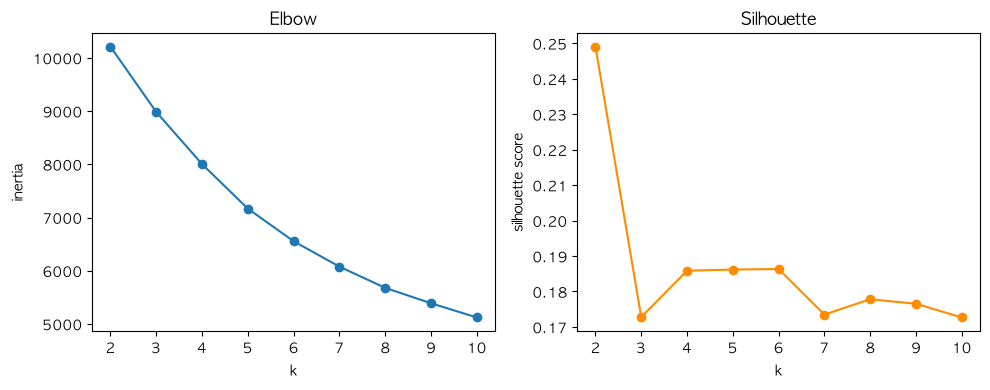

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_table["k"], k_table["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow")

axes[1].plot(k_table["k"], k_table["silhouette"], marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_k_selection.png", dpi=150)
plt.show()

k=2: silhouette=0.2490, 클러스터 크기={0: 1289, 1: 571}
k=3: silhouette=0.1728, 클러스터 크기={0: 558, 1: 485, 2: 817}
k=4: silhouette=0.1859, 클러스터 크기={0: 509, 1: 811, 2: 28, 3: 512}


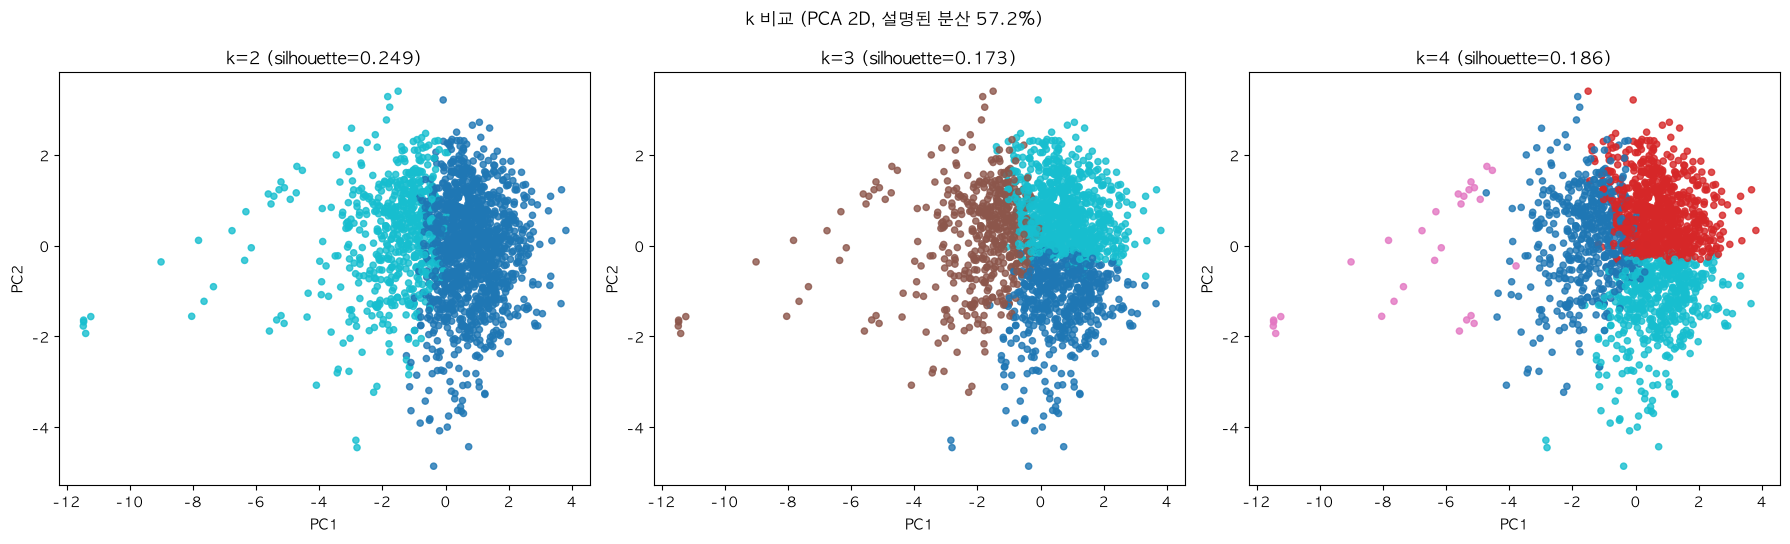

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, len(COMPARE_KS), figsize=(6 * len(COMPARE_KS), 5.5))
for ax, k in zip(np.atleast_1d(axes), COMPARE_KS):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_tmp = km.fit_predict(X_scaled)
    sil_tmp = silhouette_score(X_scaled, labels_tmp)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_tmp, cmap="tab10", s=20, alpha=0.8)
    ax.set_title(f"k={k} (silhouette={sil_tmp:.3f})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    sizes_tmp = pd.Series(labels_tmp).value_counts().sort_index().to_dict()
    print(f"k={k}: silhouette={sil_tmp:.4f}, 클러스터 크기={sizes_tmp}")

fig.suptitle(f"k 비교 (PCA 2D, 설명된 분산 {explained:.1%})")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_k_comparison.png", dpi=150)
plt.show()

## 5. 최종 k 확정 → 재학습 → 클러스터 프로파일링

설정 셀의 `FINAL_K`(현재 3)로 최종 학습한다. k를 바꾸고 싶으면 설정 셀에서 값을 바꾼 뒤 이 절부터 다시 실행.

In [12]:
final_km = KMeans(n_clusters=FINAL_K, n_init=10, random_state=RANDOM_STATE)
labels = final_km.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, labels)

profile["cluster"] = labels
profile["silhouette_sample"] = silhouette_samples(X_scaled, labels)

print(f"최종 k={FINAL_K}, silhouette={sil_final:.4f}")
profile["cluster"].value_counts().sort_index()

최종 k=3, silhouette=0.1728


cluster
0    558
1    485
2    817
Name: count, dtype: int64

In [ ]:
cluster_profile = profile.groupby("cluster")[FEATURE_COLS].agg(["mean", "std"]).round(2)
cluster_profile.to_csv(OUTPUT_DIR / "kmeans_cluster_profile.csv")
cluster_profile

**해석** (실제 데이터 1,860개 투수-시즌 기준 결과)

| 클러스터 | 구속 | IVB(상하) | HB(좌우) | 팔각도 | 특징 |
|---|---|---|---|---|---|
| 0 | 92.1 | 14.1 | 5.6 | 45.9 | 일반 라이징 포심 |
| 1 | 93.5 | 7.9 (낮음) | 14.5 (높음) | 25.5 (낮음) | 싱커 계열 — 팔각도 낮아 좌우 무브먼트 큼 |
| 2 | 95.3 (빠름) | 16.9 (높음) | 7.8 | 42.7 | 엘리트급 라이징 포심 |

팔각도가 낮을수록 좌우 움직임(HB)이 커지고 상하 움직임(IVB)이 작아지는 물리적 관계가 뚜렷하게 나타남
→ 단순히 분포를 억지로 자른 것이 아니라 의미 있는 구조로 판단됨.

> ⚠️ 클러스터 **번호(0/1/2)** 는 데이터나 scikit-learn 버전이 바뀌면 달라질 수 있다.
> 바로 위 프로필 표의 평균값을 보고 이 해석표와 번호가 맞는지 확인할 것.

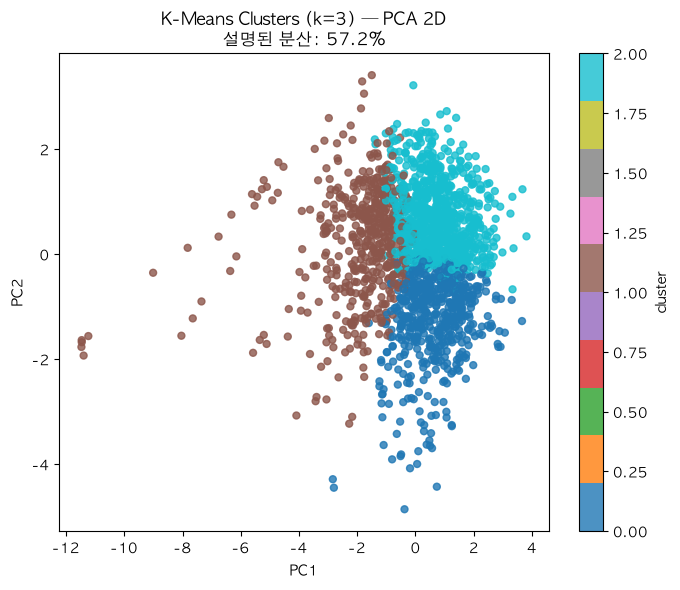

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
ax.set_title(f"K-Means Clusters (k={FINAL_K}) — PCA 2D\n설명된 분산: {explained:.1%}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="cluster")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kmeans_pca_clusters.png", dpi=150)
plt.show()

## 6. 검증: 클러스터 vs 실제 구종(FF/SI/FC) 교차표

팔각도가 낮은 클러스터가 실제로 싱커(SI) 투수들과 겹치는지 확인한다.
일치도가 높으면 위 해석(팔각도 ↔ 무브먼트 방향)이 데이터로 뒷받침되는 것.

In [14]:
crosstab = pd.crosstab(
    profile["cluster"], profile["primary_fastball_type"],
    margins=True, margins_name="합계",
)
crosstab

primary_fastball_type,FC,FF,SI,합계
cluster,,,,
0,88,403,67,558
1,1,146,338,485
2,17,743,57,817
합계,106,1292,462,1860


In [15]:
crosstab_pct = (pd.crosstab(
    profile["cluster"], profile["primary_fastball_type"],
    normalize="index",
) * 100).round(1)
crosstab_pct.columns = [f"{c} (%)" for c in crosstab_pct.columns]
crosstab_pct

,FC (%),FF (%),SI (%)
cluster,,,
0,15.8,72.2,12.0
1,0.2,30.1,69.7
2,2.1,90.9,7.0


**교차표 해석**
- 실제 데이터 결과: 클러스터 1은 **SI 69.7%**, 클러스터 2는 **FF 90.9%**, 클러스터 0은 FF 72.2% + FC 15.8%
  → "팔각도 낮음 = 싱커 계열" 해석이 검증됨. (FC는 대부분 클러스터 0에 속해 컷터는 별도 그룹으로 갈라지지 않음)
- 만약 세 클러스터 모두 FF 비율이 압도적이고 구종과 무관하다면 → 클러스터가 구종이 아니라
  같은 포심 안에서의 "스타일 차이"(라이징 vs 일반)를 포착한 것으로 재해석해야 함.

### 팀 비교용 지표 저장 (계층적 / DBSCAN / GNN)

동일한 기준(실루엣 점수, 클러스터 수, 클러스터별 크기, 노이즈 처리 여부)으로 정리해서
발표 때 다른 클러스터링 기법과 나란히 비교할 수 있게 한다.

In [16]:
sizes = profile["cluster"].value_counts().sort_index()
metrics = {
    "method": "KMeans",
    "unit": "pitcher-season (primary fastball)",
    "features": FEATURE_COLS,
    "n_clusters": int(FINAL_K),
    "silhouette_score": round(float(sil_final), 4),
    "cluster_sizes": {int(c): int(n) for c, n in sizes.items()},
    "noise_points": 0,
    "notes": (
        "K-Means는 구형(spherical) 클러스터를 가정하고 k를 사전에 지정해야 함. "
        "DBSCAN과 달리 이상치를 별도 노이즈로 분리하지 않고 모든 투수-시즌을 "
        "클러스터에 할당함. 계층적/GNN 결과와 클러스터 수·크기 비교 시 참고."
    ),
}

with open(OUTPUT_DIR / "kmeans_comparison_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

metrics

{'method': 'KMeans',
 'unit': 'pitcher-season (primary fastball)',
 'features': ['release_speed',
  'ivb_ft',
  'hb_ft',
  'arm_angle',
  'release_pos_x',
  'release_pos_z',
  'release_extension'],
 'n_clusters': 3,
 'silhouette_score': 0.1728,
 'cluster_sizes': {0: 558, 1: 485, 2: 817},
 'noise_points': 0,
 'notes': 'K-Means는 구형(spherical) 클러스터를 가정하고 k를 사전에 지정해야 함. DBSCAN과 달리 이상치를 별도 노이즈로 분리하지 않고 모든 투수-시즌을 클러스터에 할당함. 계층적/GNN 결과와 클러스터 수·크기 비교 시 참고.'}

### 최종 결과 저장

In [17]:
out_path = OUTPUT_DIR / "fastball_clusters_final.csv"
profile.to_csv(out_path, index=False, encoding="utf-8-sig")   # 엑셀에서 열어도 한글 안 깨지게
print(f"저장 완료: {rel(out_path)} ({len(profile):,}행)")
print("\n[산출물 목록]")
for p in sorted(OUTPUT_DIR.glob("kmeans_*")) + [out_path]:
    print(" -", p.name)

저장 완료: data/processed/output/fastball_clusters_final.csv (1,860행)

[산출물 목록]
 - kmeans_comparison_metrics.json
 - kmeans_k_comparison.png
 - kmeans_k_selection.csv
 - kmeans_k_selection.png
 - kmeans_pca_clusters.png
 - fastball_clusters_final.csv


## 결론 요약

1. **k 결정**: silhouette 지표만으로는 k=2가 최적이지만, k=3에서 클러스터별 프로필이 팔각도-무브먼트 방향의
   물리적 관계를 뚜렷하게 반영하여 **k=3을 최종 채택**함.
2. **클러스터 해석**:
   - 클러스터 0: 일반 라이징 포심 (팔각도 높음, IVB 중간)
   - 클러스터 1: 싱커 계열 (팔각도 낮음, HB 큼, IVB 작음)
   - 클러스터 2: 엘리트급 라이징 포심 (구속·IVB 모두 최고)
3. **검증**: `primary_fastball_type` 교차표에서 클러스터 1의 SI 비율 69.7%, 클러스터 2의 FF 비율 90.9%로 해석이 뒷받침됨.
4. **비교 지표**: 실루엣 점수, 클러스터 수/크기, 노이즈 처리 여부를 `kmeans_comparison_metrics.json`으로 정리함.
5. **산출물** (`data/processed/output/`):
   - `fastball_clusters_final.csv` — 투수-시즌별 클러스터 라벨 + 샘플별 silhouette
   - `kmeans_k_selection.csv/.png` — k별 inertia / silhouette
   - `kmeans_cluster_profile.csv` — 클러스터별 평균/표준편차
   - `kmeans_k_comparison.png`, `kmeans_pca_clusters.png` — PCA 시각화
   - `kmeans_comparison_metrics.json` — 팀 비교용 지표